In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Number of classes:", len(np.unique(y_train)))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)
Number of classes: 10


In [3]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

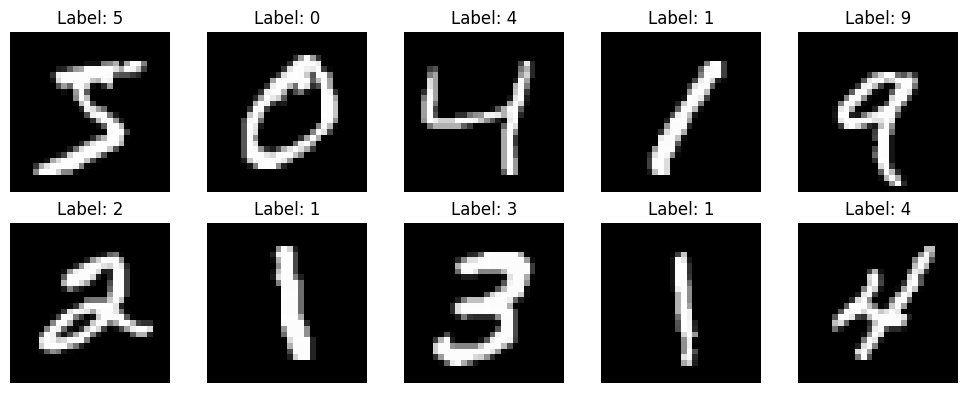

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
def build_sigmoid_model():

    model = Sequential()

    model.add(Flatten(input_shape=(28, 28)))

    for _ in range(10):
        model.add(
            Dense(
                128,
                activation="sigmoid"
            )
        )

    model.add(
        Dense(
            10,
            activation="softmax"
        )
    )

    return model

In [6]:
sigmoid_model = build_sigmoid_model()

sigmoid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

sigmoid_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_sigmoid = sigmoid_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

In [7]:
test_loss, test_accuracy = sigmoid_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 2.5245120525360107
Test Accuracy: 0.09799999743700027


In [9]:
loss_function = tf.keras.losses.SparseCategoricalCrossentropy()

sample_x = X_train[:256]
sample_y = y_train[:256]

with tf.GradientTape() as tape:

    predictions = sigmoid_model(sample_x, training=True)

    loss = loss_function(
        sample_y,
        predictions
    )

gradients = tape.gradient(
    loss,
    sigmoid_model.trainable_variables
)

gradient_info = []

for variable, gradient in zip(
    sigmoid_model.trainable_variables,
    gradients
):

    if gradient is not None:

        gradient_info.append({
            "Layer": variable.name,
            "Mean Gradient": tf.reduce_mean(
                tf.abs(gradient)
            ).numpy()
        })

gradient_df = pd.DataFrame(gradient_info)

gradient_df

,Layer,Mean Gradient
0,kernel,1.571100e-09
1,bias,8.488110e-09
2,kernel,1.800497e-08
3,bias,3.541205e-08
4,kernel,7.753223e-08
5,bias,1.534787e-07
6,kernel,2.910506e-07
7,bias,6.076388e-07
8,kernel,1.334860e-06
9,bias,2.644577e-06


In [10]:
def build_relu_model():

    model = Sequential()

    model.add(
        Flatten(input_shape=(28, 28))
    )

    for _ in range(10):

        model.add(
            Dense(
                128,
                activation="relu",
                kernel_initializer="he_normal"
            )
        )

    model.add(
        Dense(
            10,
            activation="softmax"
        )
    )

    return model

In [11]:
relu_model = build_relu_model()

relu_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

relu_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_relu = relu_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8988 - loss: 0.3319 - val_accuracy: 0.9498 - val_loss: 0.1712
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9571 - loss: 0.1431 - val_accuracy: 0.9573 - val_loss: 0.1511
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9685 - loss: 0.1067 - val_accuracy: 0.9673 - val_loss: 0.1151
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9761 - loss: 0.0821 - val_accuracy: 0.9672 - val_loss: 0.1104
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9787 - loss: 0.0728 - val_accuracy: 0.9688 - val_loss: 0.1060
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9817 - loss: 0.0613 - val_accuracy: 0.9632 - val_loss: 0.1399
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9833 - loss: 0.0555 - val_accuracy: 0.9738 - val_loss: 0.0999
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9847 - loss: 0.0496 - val_accuracy: 0.

In [13]:
relu_loss, relu_accuracy = relu_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("ReLU Test Loss:", relu_loss)
print("ReLU Test Accuracy:", relu_accuracy)

ReLU Test Loss: 0.12367527931928635
ReLU Test Accuracy: 0.9742000102996826


In [14]:
mnist_comparison = pd.DataFrame({
    "Model": [
        "10-Layer Sigmoid",
        "10-Layer ReLU + He"
    ],
    "Test Accuracy": [
        test_accuracy,
        relu_accuracy
    ],
    "Test Loss": [
        test_loss,
        relu_loss
    ]
})

mnist_comparison

,Model,Test Accuracy,Test Loss
0,10-Layer Sigmoid,0.0980,2.524512
1,10-Layer ReLU + He,0.9742,0.123675


Case Study 2 — Boston Housing Regression

In [15]:
from tensorflow.keras.datasets import boston_housing

(X_train_boston, y_train_boston), (
    X_test_boston,
    y_test_boston
) = boston_housing.load_data()

print("Training shape:", X_train_boston.shape)
print("Testing shape:", X_test_boston.shape)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Training shape: (404, 13)
Testing shape: (102, 13)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_boston = scaler.fit_transform(
    X_train_boston
)

X_test_boston = scaler.transform(
    X_test_boston
)

In [17]:
def build_exploding_model():

    model = Sequential()

    model.add(
        Dense(
            128,
            activation="relu",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=2.0
            ),
            input_shape=(X_train_boston.shape[1],)
        )
    )

    for _ in range(7):

        model.add(
            Dense(
                128,
                activation="relu",
                kernel_initializer=tf.keras.initializers.RandomNormal(
                    mean=0.0,
                    stddev=2.0
                )
            )
        )

    model.add(
        Dense(1)
    )

    return model

In [18]:
exploding_model = build_exploding_model()

exploding_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.01
    ),
    loss="mse",
    metrics=["mae"]
)

exploding_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,505 (459.00 KB)

 Trainable params: 117,505 (459.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_exploding = exploding_model.fit(
    X_train_boston,
    y_train_boston,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - loss: 659148562197643264.0000 - mae: 614680384.0000 - val_loss: 225681582009090048.0000 - val_mae: 408483328.0000
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 155565897304506368.0000 - mae: 284816960.0000 - val_loss: 11803944518942720.0000 - val_mae: 82744472.0000
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37322428283617280.0000 - mae: 136904512.0000 - val_loss: 32495973817122816.0000 - val_mae: 151441936.0000
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 60791087366668288.0000 - mae: 181614656.0000 - val_loss: 27015241212624896.0000 - val_mae: 145721312.0000
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29531132122890240.0000 - mae: 117090504.0000 - val_loss: 11597396320452608.0000 - val_mae: 81844112.0000
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14415412410187776.0000 - mae: 83003896.0000 - val_loss: 8113442330247168.0000 - val_mae: 71529216.0000
Epoch 7/30
11/1

In [20]:
mse = tf.keras.losses.MeanSquaredError()

sample_x = X_train_boston[:64]
sample_y = y_train_boston[:64]

with tf.GradientTape() as tape:

    predictions = exploding_model(
        sample_x,
        training=True
    )

    loss = mse(
        sample_y,
        predictions
    )

gradients = tape.gradient(
    loss,
    exploding_model.trainable_variables
)

exploding_gradient_info = []

for variable, gradient in zip(
    exploding_model.trainable_variables,
    gradients
):

    if gradient is not None:

        exploding_gradient_info.append({
            "Layer": variable.name,
            "Mean Gradient": tf.reduce_mean(
                tf.abs(gradient)
            ).numpy(),
            "Max Gradient": tf.reduce_max(
                tf.abs(gradient)
            ).numpy()
        })

exploding_gradient_df = pd.DataFrame(
    exploding_gradient_info
)

exploding_gradient_df

,Layer,Mean Gradient,Max Gradient
0,kernel,7.335136e+12,6.927017e+13
1,bias,7.402820e+12,2.321105e+13
2,kernel,2.054502e+12,3.186942e+13
3,bias,4.887928e+11,2.228654e+12
4,kernel,1.543122e+12,3.484695e+13
5,bias,3.502480e+10,1.709855e+11
6,kernel,1.567138e+12,2.734185e+13
7,bias,2.685991e+09,1.409693e+10
8,kernel,1.521589e+12,4.244116e+13
9,bias,2.173625e+08,1.095255e+09


In [21]:
def build_stable_model():

    model = Sequential()

    model.add(
        Dense(
            128,
            activation="relu",
            kernel_initializer="he_normal",
            input_shape=(X_train_boston.shape[1],)
        )
    )

    for _ in range(7):

        model.add(
            Dense(
                128,
                activation="relu",
                kernel_initializer="he_normal"
            )
        )

    model.add(
        Dense(1)
    )

    return model

In [22]:
stable_model = build_stable_model()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

stable_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
history_stable = stable_model.fit(
    X_train_boston,
    y_train_boston,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 222.1534 - mae: 11.9806 - val_loss: 60.0036 - val_mae: 6.3040
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 54.0360 - mae: 5.4898 - val_loss: 33.9457 - val_mae: 4.7312
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25.3940 - mae: 3.6928 - val_loss: 19.7500 - val_mae: 3.4928
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.5367 - mae: 2.9346 - val_loss: 18.8583 - val_mae: 3.1741
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.5620 - mae: 2.5989 - val_loss: 16.4415 - val_mae: 3.0217
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.2514 - mae: 2.5236 - val_loss: 21.2927 - val_mae: 3.2942
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 10.0572 - mae: 2.3579 - val_loss: 29.0694 - val_mae: 3.7905
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.7041 - mae: 2.4960 - val_loss: 32.6511 - val_mae: 3.9923
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms

In [24]:
stable_loss, stable_mae = stable_model.evaluate(
    X_test_boston,
    y_test_boston,
    verbose=0
)

print("Test MSE:", stable_loss)
print("Test MAE:", stable_mae)

Test MSE: 20.516714096069336
Test MAE: 2.9356353282928467


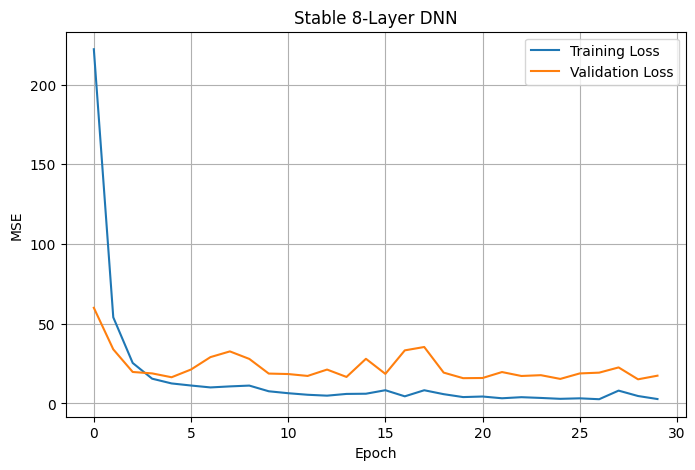

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stable.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_stable.history["val_loss"],
    label="Validation Loss"
)

plt.title("Stable 8-Layer DNN")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()

plt.show()

In [26]:
final_comparison = pd.DataFrame({
    "Case Study": [
        "MNIST",
        "MNIST",
        "Boston Housing",
        "Boston Housing"
    ],

    "Model": [
        "10-Layer Sigmoid",
        "10-Layer ReLU + He",
        "8-Layer Large Weights",
        "8-Layer Stable + Clipping"
    ],

    "Problem/Solution": [
        "Vanishing Gradient",
        "Improved Gradient Flow",
        "Exploding Gradient",
        "Gradient Clipping"
    ],

    "Metric": [
        test_accuracy,
        relu_accuracy,
        np.min(history_exploding.history["loss"]),
        stable_mae
    ]
})

final_comparison

,Case Study,Model,Problem/Solution,Metric
0,MNIST,10-Layer Sigmoid,Vanishing Gradient,9.800000e-02
1,MNIST,10-Layer ReLU + He,Improved Gradient Flow,9.742000e-01
2,Boston Housing,8-Layer Large Weights,Exploding Gradient,4.136270e+13
3,Boston Housing,8-Layer Stable + Clipping,Gradient Clipping,2.935635e+00
